# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [15]:
!curl -L -o SUSY.csv.gz http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  4691k      0 --:--:--  0:03:11 --:--:-- 6495k


In [16]:
!ls -lh

total 6976800
-rw-r--r--  1 sunaihra_zeb  staff   1.1M Apr 24 09:10 Lab.7.ipynb
-rw-r--r--  1 sunaihra_zeb  staff   5.8M Mar 17 13:26 Lab.7.pdf
-rw-r--r--  1 sunaihra_zeb  staff   228M Apr 23 13:17 SUSY-small.csv
-rw-r--r--  1 sunaihra_zeb  staff   2.2G Apr 23 13:33 SUSY.csv
-rw-r--r--  1 sunaihra_zeb  staff   880M Apr 24 09:09 SUSY.csv.gz


The data is provided as a comma separated file.

In [17]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [18]:
!ls -lh

total 6976800
-rw-r--r--  1 sunaihra_zeb  staff   1.1M Apr 24 09:12 Lab.7.ipynb
-rw-r--r--  1 sunaihra_zeb  staff   5.8M Mar 17 13:26 Lab.7.pdf
-rw-r--r--  1 sunaihra_zeb  staff   228M Apr 23 13:17 SUSY-small.csv
-rw-r--r--  1 sunaihra_zeb  staff   2.2G Apr 23 13:33 SUSY.csv
-rw-r--r--  1 sunaihra_zeb  staff   880M Apr 24 09:09 SUSY.csv.gz


We see that we have 5 million datapoints.

In [19]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [20]:
!head -500000 SUSY.csv > SUSY-small.csv

In [21]:
ls -lh

total 7001592
-rw-r--r--  1 sunaihra_zeb  staff   1.1M Apr 24 09:12 Lab.7.ipynb
-rw-r--r--  1 sunaihra_zeb  staff   5.8M Mar 17 13:26 Lab.7.pdf
-rw-r--r--  1 sunaihra_zeb  staff   228M Apr 24 09:12 SUSY-small.csv
-rw-r--r--  1 sunaihra_zeb  staff   2.2G Apr 23 13:33 SUSY.csv
-rw-r--r--  1 sunaihra_zeb  staff   880M Apr 24 09:09 SUSY.csv.gz


In [22]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [23]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [24]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [25]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [26]:
FeatureNames

['cos_theta_r1',
 'M_TR_2',
 'M_Delta_R',
 'M_R',
 'R',
 'dPhi_r_b',
 'MET_rel',
 'axial_MET',
 'MT2',
 'S_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [28]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [29]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [30]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


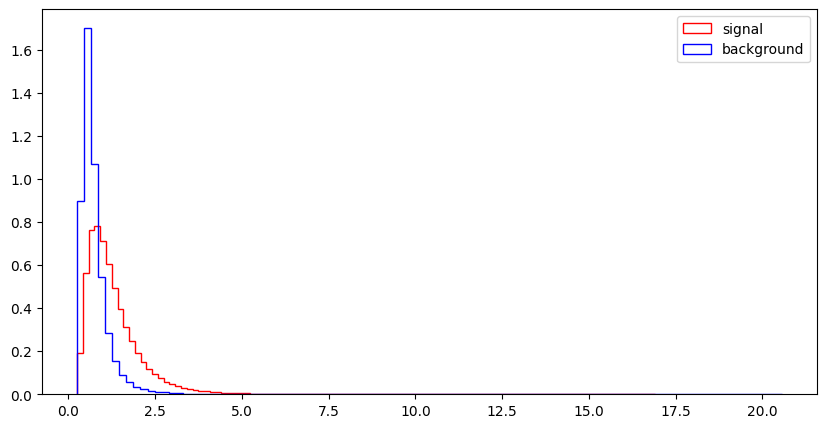

l_1_eta


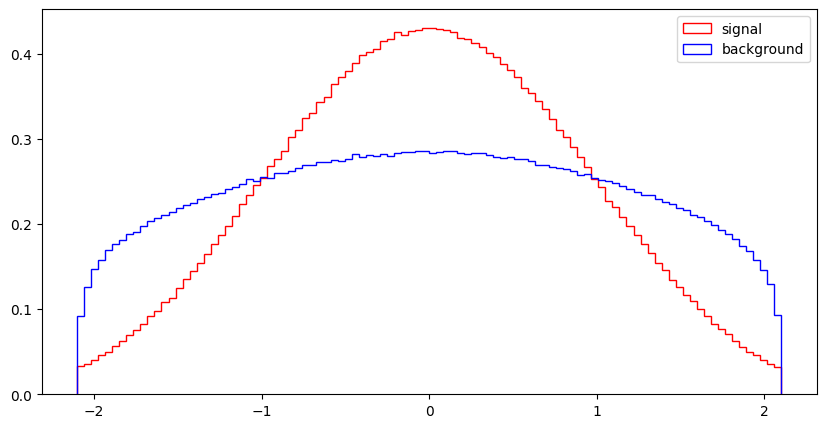

l_1_phi


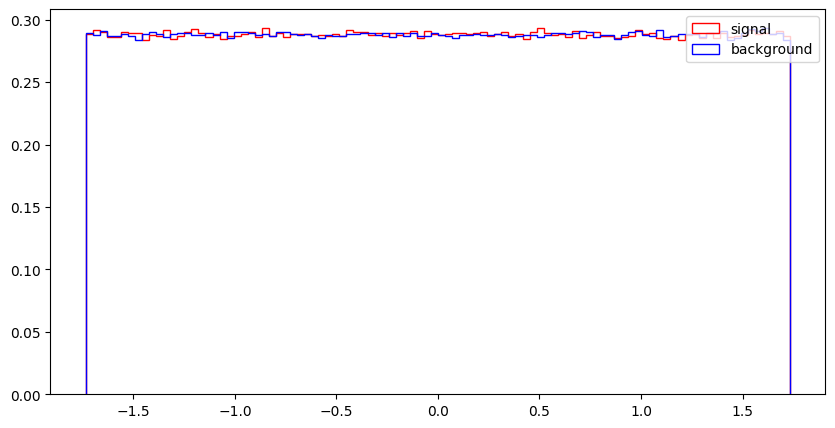

l_2_pT


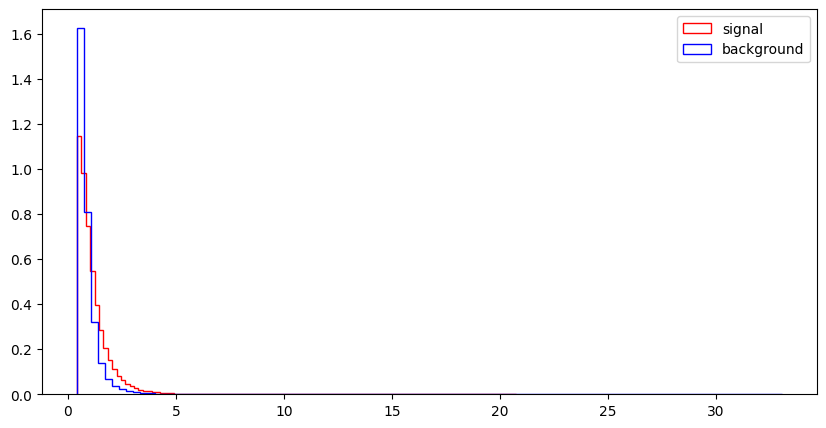

l_2_eta


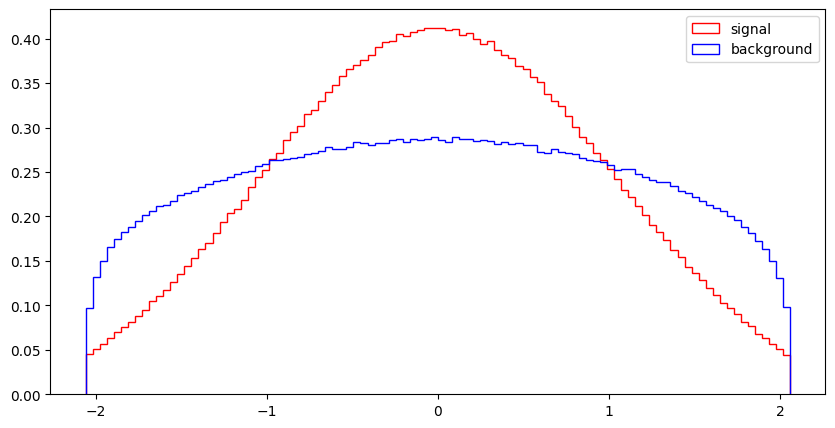

l_2_phi


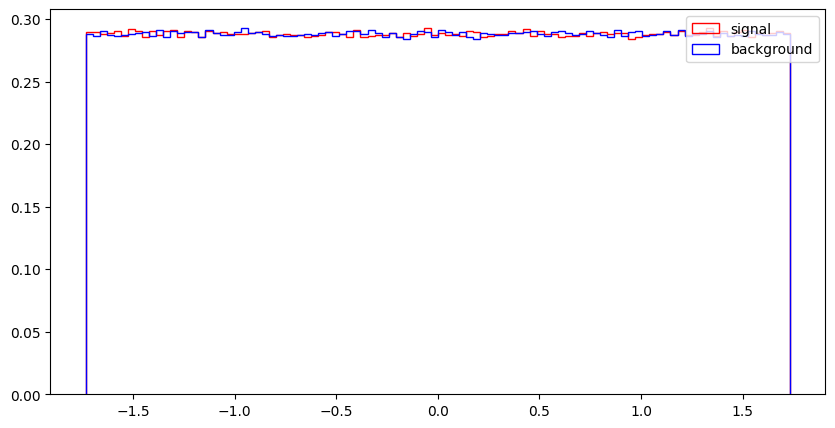

MET


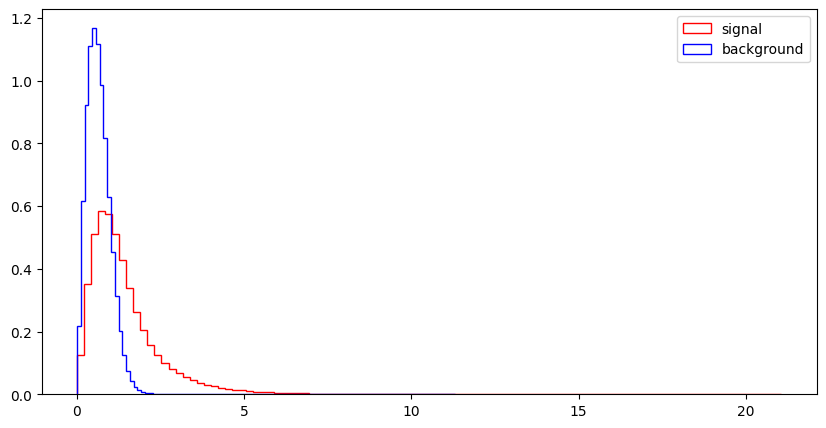

MET_phi


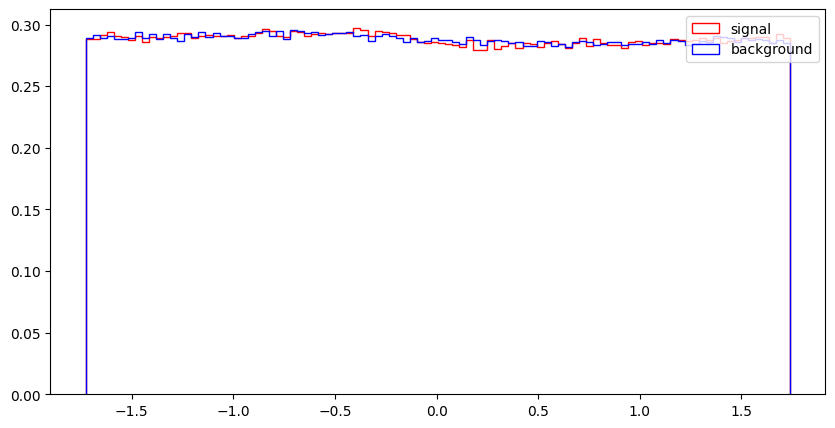

MET_rel


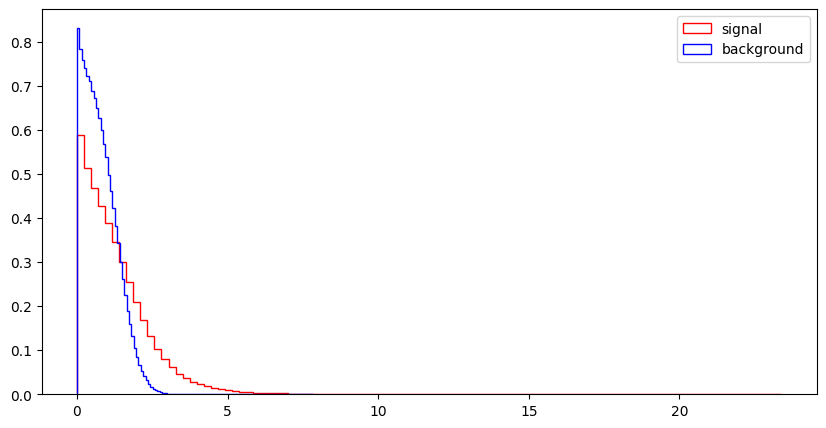

axial_MET


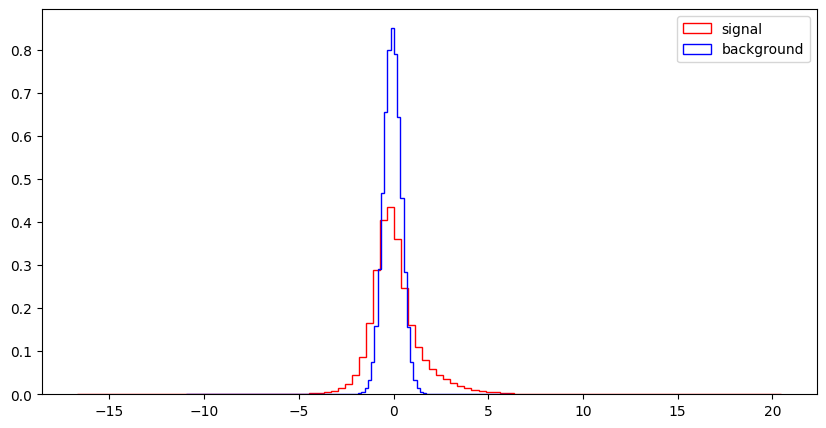

M_R


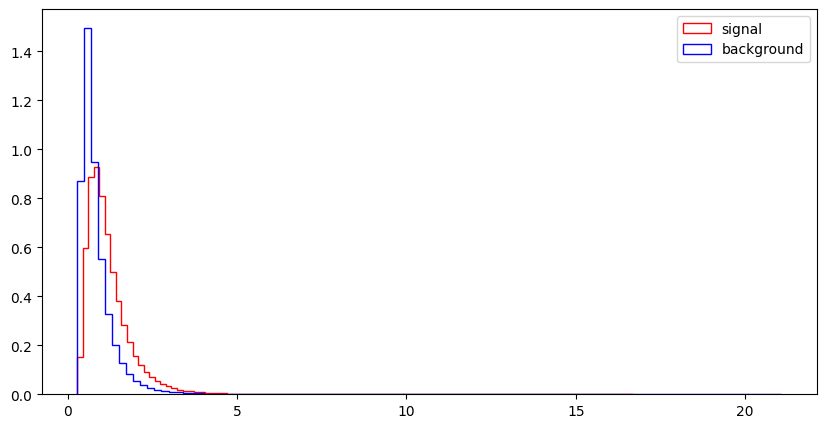

M_TR_2


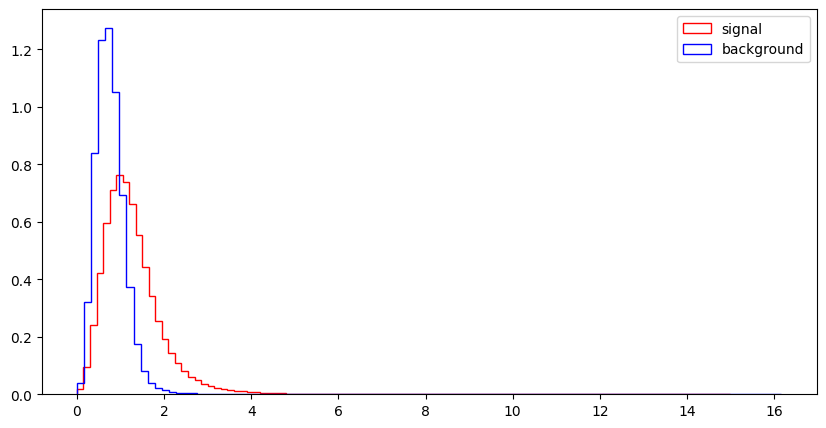

R


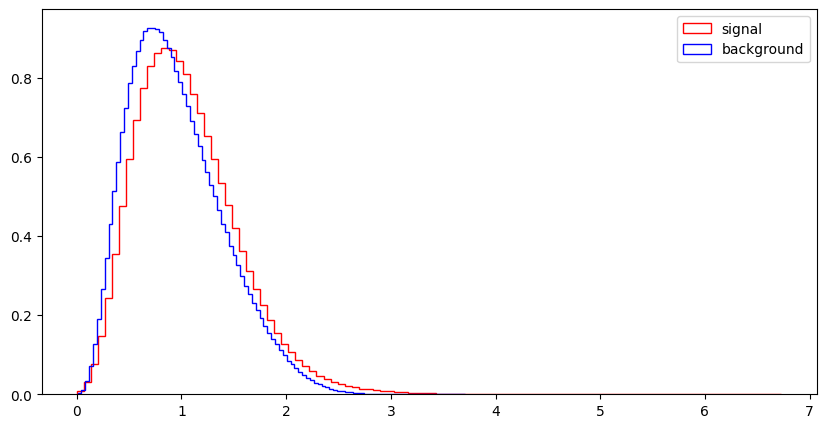

MT2


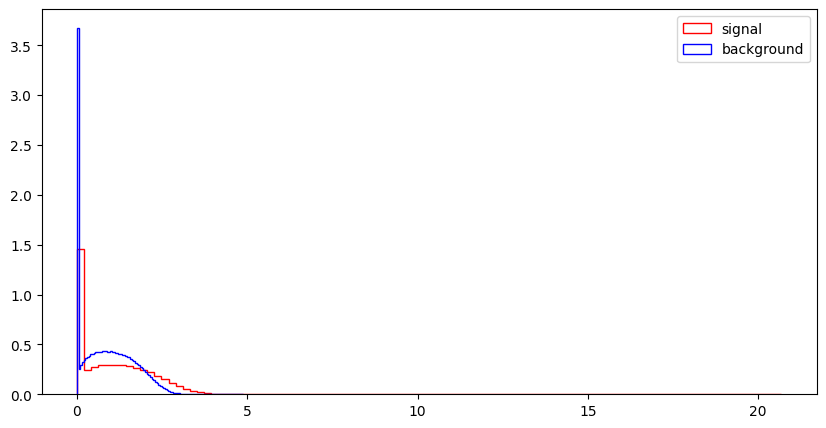

S_R


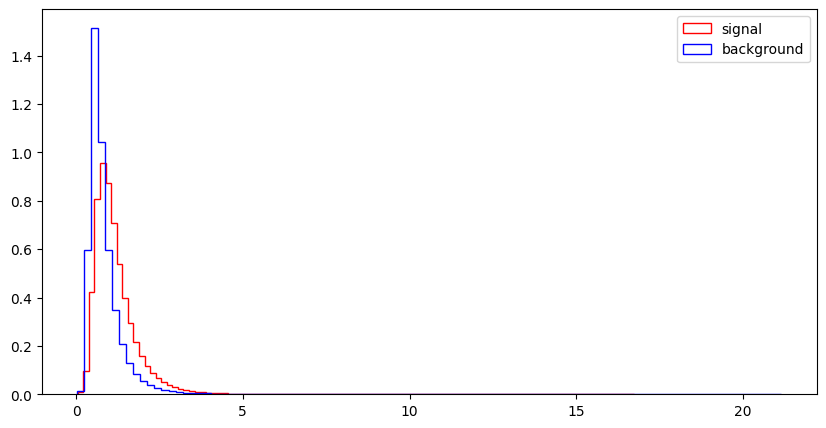

M_Delta_R


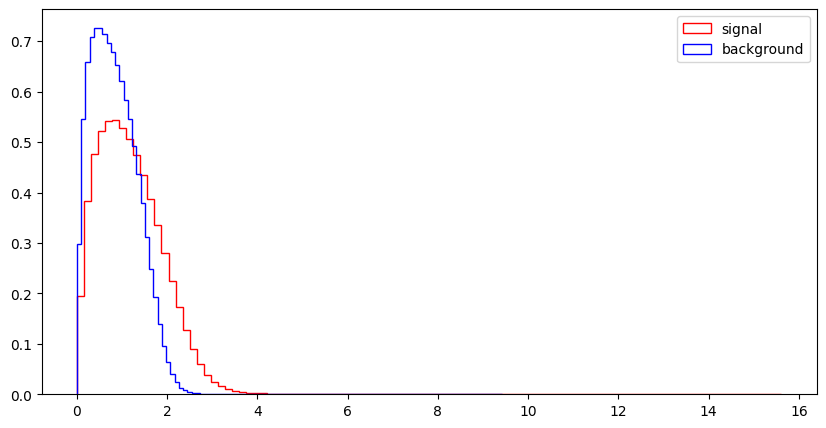

dPhi_r_b


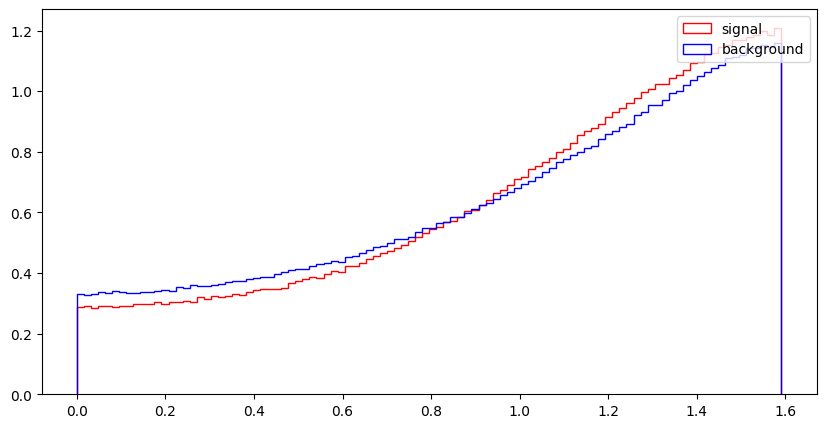

cos_theta_r1


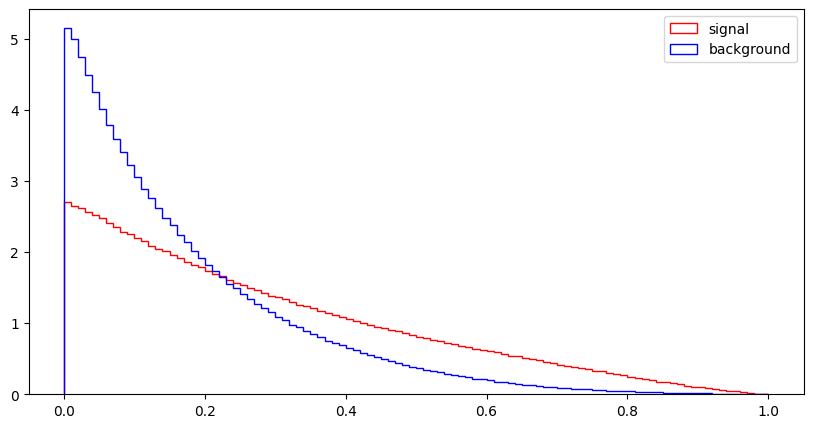

In [31]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

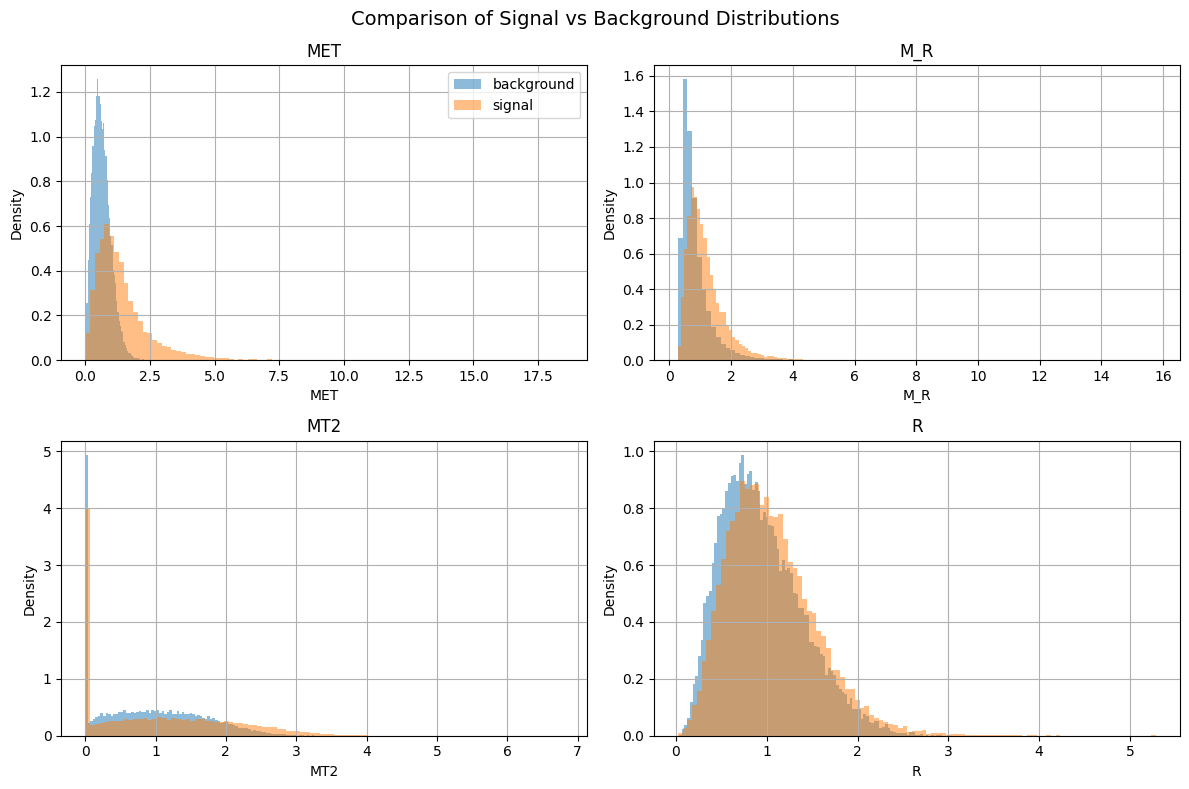

In [32]:
import matplotlib.pyplot as plt

df_sample = df.sample(50000, random_state=42)
df_sig = df_sample[df_sample.signal == 1]
df_bkg = df_sample[df_sample.signal == 0]

vars_to_plot = ["MET", "M_R", "MT2", "R"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    var = vars_to_plot[i]
    
    ax.hist(df_bkg[var], bins=100, density=True, alpha=0.5, label="background")
    ax.hist(df_sig[var], bins=100, density=True, alpha=0.5, label="signal")
    
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.set_ylabel("Density")
    ax.grid(True)

axes[0,0].legend()

plt.suptitle("Comparison of Signal vs Background Distributions", fontsize=14)
plt.tight_layout()
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

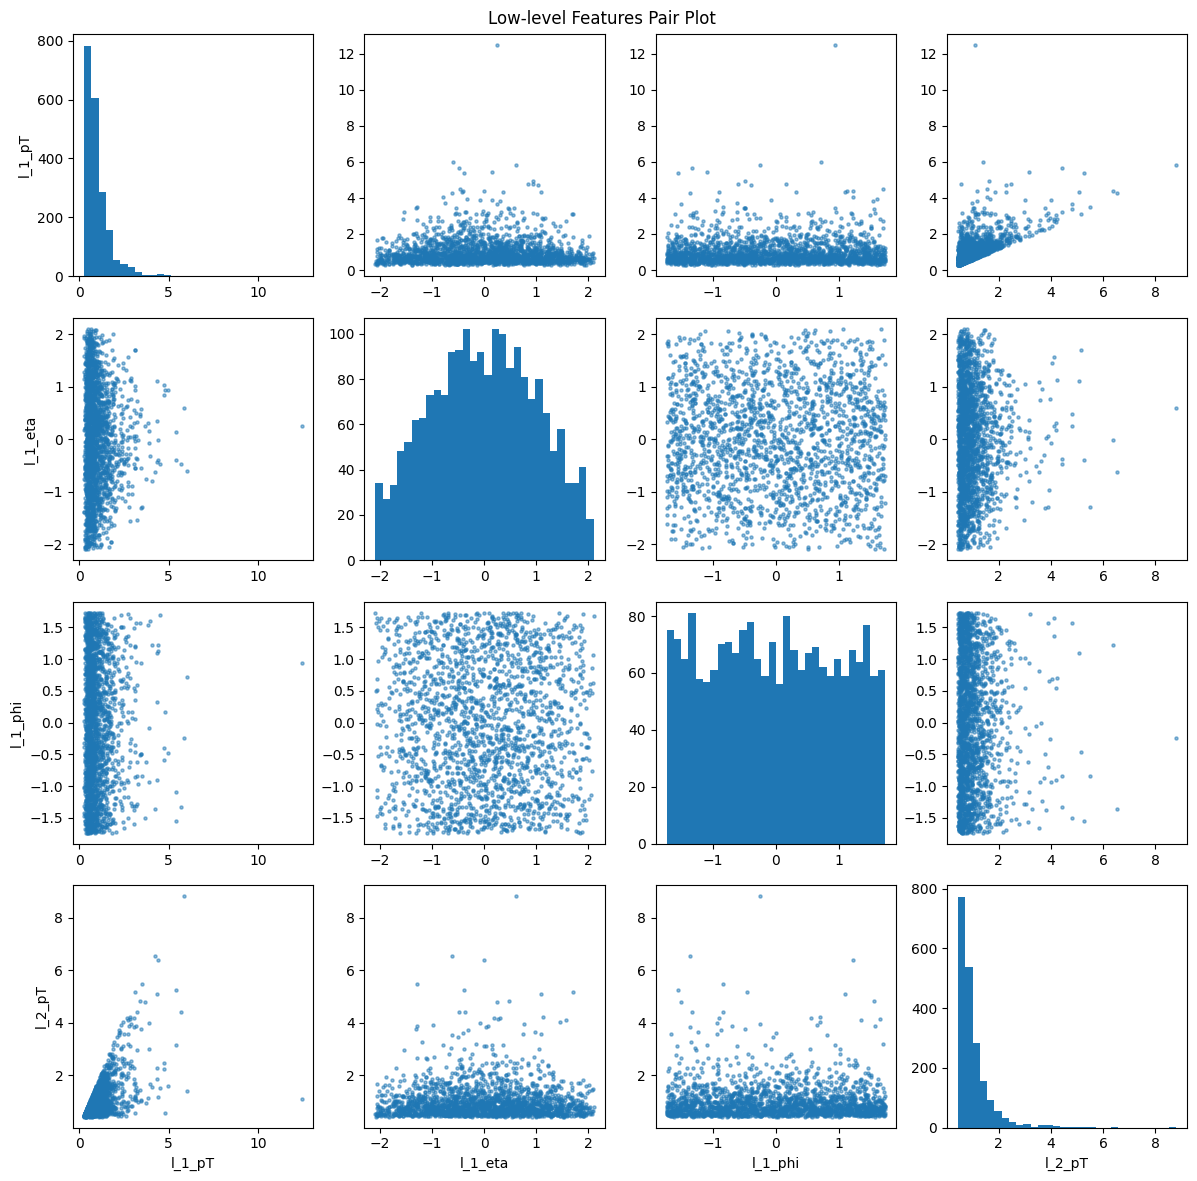

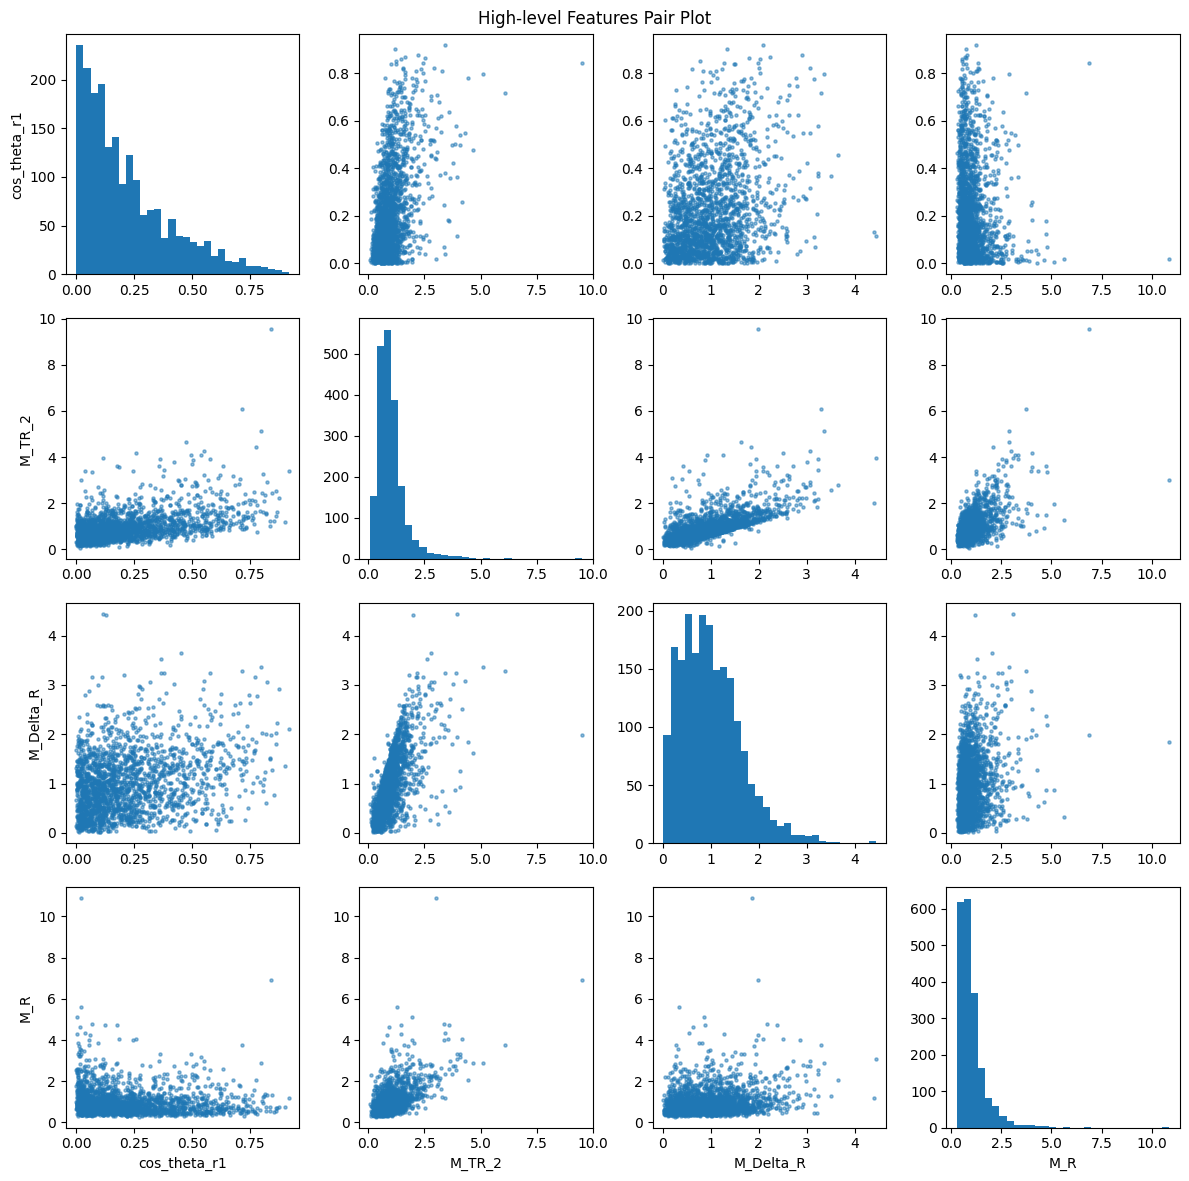

In [33]:
import matplotlib.pyplot as plt

df_sample = df.sample(2000, random_state=42)

def pair_plot(df, variables, title):
    n = len(variables)
    fig, axes = plt.subplots(n, n, figsize=(3*n, 3*n))

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            if i == j:
                # Histogram on diagonal
                ax.hist(df[variables[i]], bins=30)
            else:
                # Scatter plot
                ax.scatter(df[variables[j]], df[variables[i]], s=5, alpha=0.5)

            if i == n - 1:
                ax.set_xlabel(variables[j])
            if j == 0:
                ax.set_ylabel(variables[i])

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


RawNames = ["l_1_pT", "l_1_eta", "l_1_phi",
            "l_2_pT", "l_2_eta", "l_2_phi",
            "MET", "MET_phi"]

FeatureNames = list(set(VarNames[1:]).difference(RawNames))

pair_plot(df_sample, RawNames[:4], "Low-level Features Pair Plot")
pair_plot(df_sample, FeatureNames[:4], "High-level Features Pair Plot")

In [34]:
#To speed up the pair plot, we reduced the dataset size by sampling a subset of the data instead of using the full dataset. This significantly reduces computation time for scatter plots and histograms.
#Variables such as MET, M_R, MT2, and R appear to best separate signal from background, as their distributions show clearer differences between the two classes compared to other variables.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

Hint: Example code for embedding a `tabulate` table into a notebook:

In [35]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [36]:
import sys
!{sys.executable} -m pip install tabulate

In [39]:
import numpy as np
from tabulate import tabulate
from IPython.display import HTML, display

RawNames = ["l_1_pT", "l_1_eta", "l_1_phi",
            "l_2_pT", "l_2_eta", "l_2_phi",
            "MET", "MET_phi"]

FeatureNames = list(set(VarNames[1:]).difference(RawNames))

df_sample = df.sample(5000, random_state=42)

def show_matrices_tabulate(df, variables, title):
    data = df[variables]

    cov_matrix = np.cov(data, rowvar=False)
    corr_matrix = np.corrcoef(data, rowvar=False)

    print(f"\n===== {title} =====\n")

    display(HTML("<b>Covariance Matrix</b>"))
    display(HTML(tabulate(cov_matrix,
                          headers=variables,
                          tablefmt="html",
                          floatfmt=".3f")))

    display(HTML("<b>Correlation Matrix</b>"))
    display(HTML(tabulate(corr_matrix,
                          headers=variables,
                          tablefmt="html",
                          floatfmt=".3f")))

show_matrices_tabulate(df_sample, RawNames, "Low-level Features")
show_matrices_tabulate(df_sample, FeatureNames[:8], "High-level Features")


===== Low-level Features =====



l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
0.492,0.005,-0.001,0.297,-0.007,0.012,0.274,-0.016
0.005,1.018,-0.011,0.004,0.403,-0.008,0.011,-0.010
-0.001,-0.011,1.007,-0.003,-0.014,-0.268,-0.012,-0.192
0.297,0.004,-0.003,0.413,-0.003,0.006,0.099,-0.009
-0.007,0.403,-0.014,-0.003,1.003,0.002,0.005,0.008
0.012,-0.008,-0.268,0.006,0.002,1.012,0.014,-0.038
0.274,0.011,-0.012,0.099,0.005,0.014,0.849,-0.017
-0.016,-0.010,-0.192,-0.009,0.008,-0.038,-0.017,0.995


l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
1.000,0.007,-0.001,0.659,-0.010,0.017,0.424,-0.022
0.007,1.000,-0.011,0.006,0.398,-0.008,0.012,-0.010
-0.001,-0.011,1.000,-0.005,-0.014,-0.265,-0.012,-0.192
0.659,0.006,-0.005,1.000,-0.005,0.009,0.167,-0.014
-0.010,0.398,-0.014,-0.005,1.000,0.002,0.005,0.008
0.017,-0.008,-0.265,0.009,0.002,1.000,0.016,-0.038
0.424,0.012,-0.012,0.167,0.005,0.016,1.000,-0.019
-0.022,-0.010,-0.192,-0.014,0.008,-0.038,-0.019,1.000



===== High-level Features =====



cos_theta_r1,M_TR_2,M_Delta_R,M_R,R,dPhi_r_b,MET_rel,axial_MET
0.039,0.053,0.039,-0.013,0.058,0.007,0.055,-0.057
0.053,0.366,0.258,0.229,0.107,0.061,0.326,-0.182
0.039,0.258,0.406,0.090,0.167,0.047,0.447,-0.236
-0.013,0.229,0.090,0.408,-0.111,-0.018,0.066,0.029
0.058,0.107,0.167,-0.111,0.225,0.085,0.256,-0.190
0.007,0.061,0.047,-0.018,0.085,0.189,0.148,-0.028
0.055,0.326,0.447,0.066,0.256,0.148,0.852,-0.107
-0.057,-0.182,-0.236,0.029,-0.190,-0.028,-0.107,1.107


cos_theta_r1,M_TR_2,M_Delta_R,M_R,R,dPhi_r_b,MET_rel,axial_MET
1.000,0.444,0.309,-0.104,0.618,0.087,0.303,-0.275
0.444,1.000,0.670,0.593,0.372,0.234,0.585,-0.286
0.309,0.670,1.000,0.222,0.553,0.168,0.759,-0.353
-0.104,0.593,0.222,1.000,-0.368,-0.066,0.112,0.043
0.618,0.372,0.553,-0.368,1.000,0.410,0.584,-0.380
0.087,0.234,0.168,-0.066,0.410,1.000,0.370,-0.062
0.303,0.585,0.759,0.112,0.584,0.370,1.000,-0.110
-0.275,-0.286,-0.353,0.043,-0.380,-0.062,-0.110,1.000


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

In [ ]:
#The optimal selection depends on how the signal distribution compares to the background:
#If signal values are generally larger → x>xc
#If signal values are smaller → x<xc
#If signal is concentrated near a mean → ∣x−μ∣<xc
#If signal lies away from a central region → ∣x−μ∣>xc
#For most important observables in this dataset, x>xc provides the best separation between signal and background.

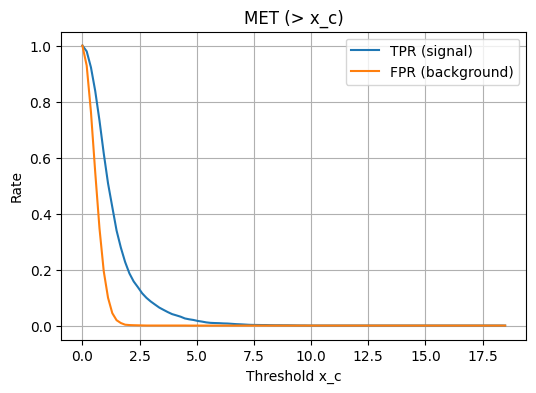

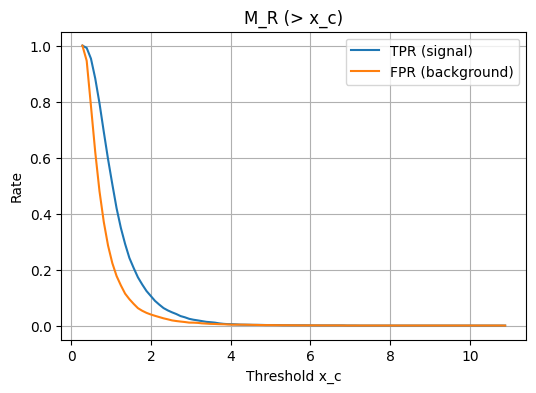

In [40]:
import numpy as np
import matplotlib.pyplot as plt

df_sample = df.sample(10000, random_state=42)
df_sig = df_sample[df_sample.signal == 1]
df_bkg = df_sample[df_sample.signal == 0]

def compute_rates(var, direction=">"):
    x_vals = np.linspace(df_sample[var].min(), df_sample[var].max(), 100)

    tpr = []
    fpr = []

    for xc in x_vals:
        if direction == ">":
            sig_pass = np.sum(df_sig[var] > xc)
            bkg_pass = np.sum(df_bkg[var] > xc)
        else:
            sig_pass = np.sum(df_sig[var] < xc)
            bkg_pass = np.sum(df_bkg[var] < xc)

        tpr.append(sig_pass / len(df_sig))
        fpr.append(bkg_pass / len(df_bkg))

    return x_vals, tpr, fpr


def plot_rates(var, direction=">"):
    x, tpr, fpr = compute_rates(var, direction)

    plt.figure(figsize=(6,4))
    plt.plot(x, tpr, label="TPR (signal)")
    plt.plot(x, fpr, label="FPR (background)")
    plt.xlabel("Threshold x_c")
    plt.ylabel("Rate")
    plt.title(f"{var} ({direction} x_c)")
    plt.legend()
    plt.grid()
    plt.show()


plot_rates("MET", ">")
plot_rates("M_R", ">")

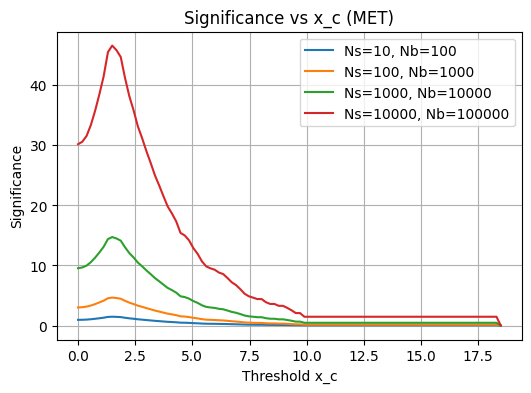

In [41]:
def compute_significance(var, Ns, Nb, direction=">"):
    x_vals = np.linspace(df_sample[var].min(), df_sample[var].max(), 100)

    sig_values = []

    for xc in x_vals:
        if direction == ">":
            eps_s = np.sum(df_sig[var] > xc) / len(df_sig)
            eps_b = np.sum(df_bkg[var] > xc) / len(df_bkg)
        else:
            eps_s = np.sum(df_sig[var] < xc) / len(df_sig)
            eps_b = np.sum(df_bkg[var] < xc) / len(df_bkg)

        Ns_prime = eps_s * Ns
        Nb_prime = eps_b * Nb

        if Ns_prime + Nb_prime > 0:
            sigma = Ns_prime / np.sqrt(Ns_prime + Nb_prime)
        else:
            sigma = 0

        sig_values.append(sigma)

    return x_vals, sig_values


def plot_significance(var, direction=">"):
    scenarios = [(10,100), (100,1000), (1000,10000), (10000,100000)]

    plt.figure(figsize=(6,4))

    for Ns, Nb in scenarios:
        x, sig = compute_significance(var, Ns, Nb, direction)
        plt.plot(x, sig, label=f"Ns={Ns}, Nb={Nb}")

    plt.xlabel("Threshold x_c")
    plt.ylabel("Significance")
    plt.title(f"Significance vs x_c ({var})")
    plt.legend()
    plt.grid()
    plt.show()


plot_significance("MET", ">")

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [ ]:
#Based on the signal and background distributions, the following observables and selection criteria were chosen:
#MET > x_c, M_R > x_c, MT2 > x_c
#These variables show clear separation, with signal events tending toward higher values than background. 
#Therefore, applying cuts of the form x>xc maximizes signal retention while reducing background.
#The variable R also shows some separation, but due to greater overlap between signal and background, 
#it is less effective compared to the others.

In [42]:
from tabulate import tabulate
import numpy as np

df_sample = df.sample(10000, random_state=42)
df_sig = df_sample[df_sample.signal == 1]
df_bkg = df_sample[df_sample.signal == 0]

Ns = 1000
Nb = 10000

cuts = [
    ("MET > 2.5", lambda df: df[df["MET"] > 2.5]),
    ("M_R > 1.5", lambda df: df[df["M_R"] > 1.5]),
    ("MT2 > 1.0", lambda df: df[df["MT2"] > 1.0]),
]

sig_current = df_sig.copy()
bkg_current = df_bkg.copy()

table = []

for name, cut in cuts:
    sig_current = cut(sig_current)
    bkg_current = cut(bkg_current)

    eps_s = len(sig_current) / len(df_sig)
    eps_b = len(bkg_current) / len(df_bkg)

    Ns_prime = eps_s * Ns
    Nb_prime = eps_b * Nb

    if Ns_prime + Nb_prime > 0:
        sigma = Ns_prime / np.sqrt(Ns_prime + Nb_prime)
    else:
        sigma = 0

    table.append([
        name,
        round(eps_s, 3),
        round(eps_b, 3),
        round(Ns_prime, 1),
        round(Nb_prime, 1),
        round(sigma, 3)
    ])

headers = ["Cut", "ε_S", "ε_B", "N_S'", "N_B'", "Significance"]
print(tabulate(table, headers=headers, tablefmt="grid"))

+-----------+-------+-------+--------+--------+----------------+
| Cut       |   ε_S |   ε_B |   N_S' |   N_B' |   Significance |
+===========+=======+=======+========+========+================+
| MET > 2.5 | 0.127 | 0.001 |  127.3 |    7.5 |         10.966 |
+-----------+-------+-------+--------+--------+----------------+
| M_R > 1.5 | 0.05  | 0.001 |   50.1 |    7.5 |          6.6   |
+-----------+-------+-------+--------+--------+----------------+
| MT2 > 1.0 | 0.017 | 0     |   17   |    3.7 |          3.74  |
+-----------+-------+-------+--------+--------+----------------+


In [ ]:
#Since observables can be correlated, optimizing cuts independently can lead to suboptimal results. Applying a cut on one variable affects the distribution of others. Re-optimizing thresholds after each cut improves performance. The order of cuts matters because correlated variables may reduce each other’s effectiveness.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



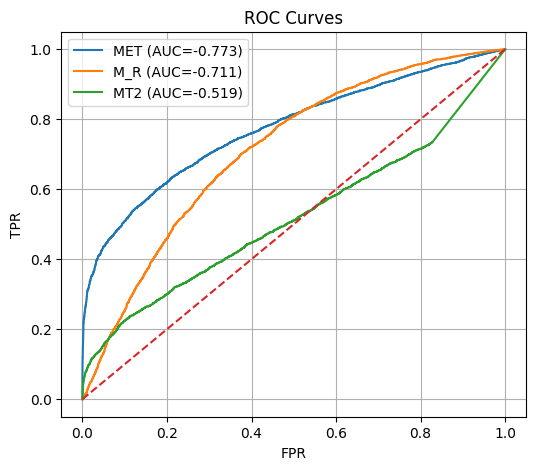

In [45]:
import numpy as np
import matplotlib.pyplot as plt

df_sample = df.sample(10000, random_state=42)

y = df_sample["signal"].values

def compute_roc(scores, y_true):
    thresholds = np.sort(scores)
    
    tpr = []
    fpr = []
    
    for t in thresholds:
        tp = np.sum((scores >= t) & (y_true == 1))
        fp = np.sum((scores >= t) & (y_true == 0))
        
        fn = np.sum((scores < t) & (y_true == 1))
        tn = np.sum((scores < t) & (y_true == 0))
        
        tpr.append(tp / (tp + fn))
        fpr.append(fp / (fp + tn))
    
    return fpr, tpr

def compute_auc(fpr, tpr):
    return np.trapezoid(tpr, fpr)

variables = ["MET", "M_R", "MT2"]

plt.figure(figsize=(6,5))

for var in variables:
    scores = df_sample[var].values
    fpr, tpr = compute_roc(scores, y)
    auc_val = compute_auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{var} (AUC={auc_val:.3f})")

plt.plot([0,1], [0,1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curves")
plt.legend()
plt.grid()

plt.show()

In [46]:
def plot_roc(df, variables):
    y = df["signal"].values
    
    plt.figure(figsize=(6,5))
    
    for var in variables:
        scores = df[var].values
        fpr, tpr = compute_roc(scores, y)
        auc_val = np.trapezoid(tpr, fpr)
        
        plt.plot(fpr, tpr, label=f"{var} (AUC={auc_val:.3f})")
    
    plt.plot([0,1], [0,1], '--')
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC Curves")
    plt.legend()
    plt.grid()
    plt.show()

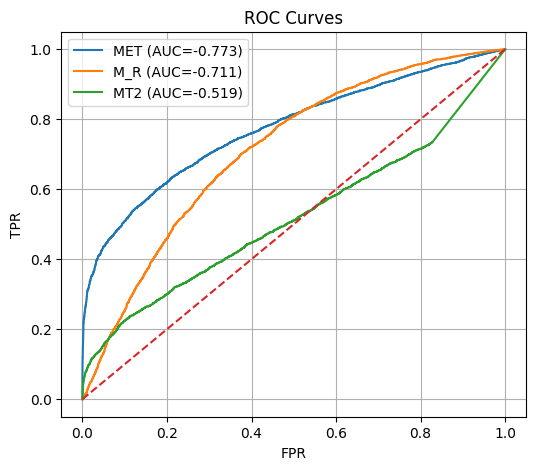

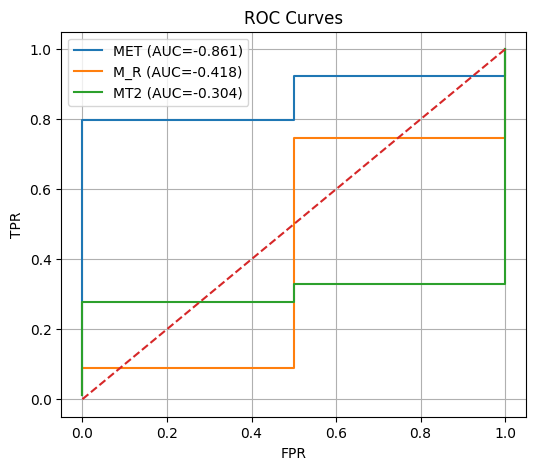

In [47]:
# Before cuts
plot_roc(df_sample, ["MET", "M_R", "MT2"])

# Apply cuts
df_cut = df_sample[(df_sample["MET"] > 2.5) &
                   (df_sample["M_R"] > 1.5) &
                   (df_sample["MT2"] > 1.0)]

# After cuts
plot_roc(df_cut, ["MET", "M_R", "MT2"])

In [ ]:
#Changing the order of cuts affects the ROC curves because variables are correlated. Applying one cut alters the distribution of remaining variables, which changes their effectiveness. Therefore, different orders can lead to different performance.

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

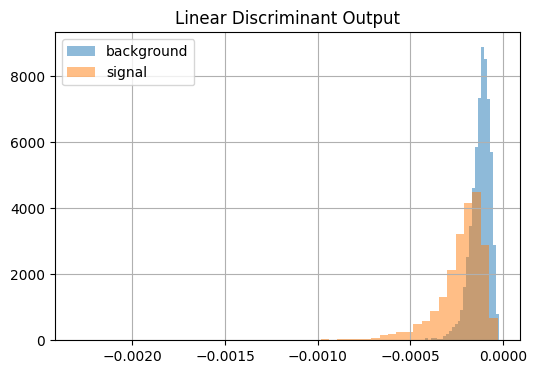

In [48]:
import numpy as np
import matplotlib.pyplot as plt

features = ["MET", "M_R", "MT2", "R"]

df_sample = df.sample(10000, random_state=42)

X = df_sample[features].values
y = df_sample["signal"].values

X_sig = X[y == 1]
X_bkg = X[y == 0]

m1 = np.mean(X_sig, axis=0)
m2 = np.mean(X_bkg, axis=0)

S_w = np.zeros((len(features), len(features)))

for x in X_sig:
    diff = (x - m1).reshape(-1,1)
    S_w += diff @ diff.T

for x in X_bkg:
    diff = (x - m2).reshape(-1,1)
    S_w += diff @ diff.T

w = np.linalg.inv(S_w) @ (m2 - m1)

F = X @ w

plt.figure(figsize=(6,4))
plt.hist(F[y==0], bins=50, alpha=0.5, label="background", density=True)
plt.hist(F[y==1], bins=50, alpha=0.5, label="signal", density=True)
plt.title("Linear Discriminant Output")
plt.legend()
plt.grid()
plt.show()

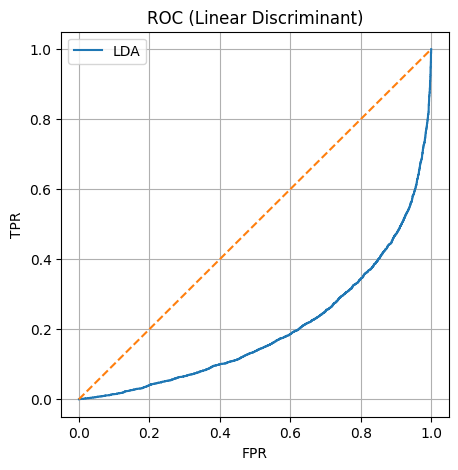

In [49]:
def compute_roc(scores, y_true):
    thresholds = np.sort(scores)
    tpr, fpr = [], []

    for t in thresholds:
        tp = np.sum((scores >= t) & (y_true == 1))
        fp = np.sum((scores >= t) & (y_true == 0))
        fn = np.sum((scores < t) & (y_true == 1))
        tn = np.sum((scores < t) & (y_true == 0))

        tpr.append(tp / (tp + fn))
        fpr.append(fp / (fp + tn))

    return fpr, tpr

fpr, tpr = compute_roc(F, y)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label="LDA")
plt.plot([0,1], [0,1], '--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC (Linear Discriminant)")
plt.legend()
plt.grid()
plt.show()

In [50]:
def compute_significance(scores, y, Ns=1000, Nb=10000):
    thresholds = np.linspace(min(scores), max(scores), 100)
    best_sigma = 0

    for t in thresholds:
        eps_s = np.sum((scores >= t) & (y==1)) / np.sum(y==1)
        eps_b = np.sum((scores >= t) & (y==0)) / np.sum(y==0)

        Ns_p = eps_s * Ns
        Nb_p = eps_b * Nb

        if Ns_p + Nb_p > 0:
            sigma = Ns_p / np.sqrt(Ns_p + Nb_p)
            best_sigma = max(best_sigma, sigma)

    return best_sigma

print("Max significance:", compute_significance(F, y))

Max significance: 9.534625892455923
